# 🚀 CUDA Fundamentals — Module 1: Basics

**GPU:** NVIDIA GeForce RTX 4070 SUPER | **CUDA:** 13.1 | **Library:** CuPy 14

## Why this matters for AI
Every AI model you've ever used — GPT, Stable Diffusion, AlphaFold — runs on GPUs.
The kernels you write in this notebook are the same primitives that power them:

| What you write here | What it becomes in AI |
|---|---|
| Vector addition | Adding bias vectors in neural network layers |
| Scalar multiply | Scaling gradients by a learning rate during training |
| Dot product / reduction | Computing attention scores, loss functions |
| Matrix–vector multiply | The forward pass of every linear layer |
| 2D thread indexing | Image processing, convolutional layers |

NVIDIA's DevTech team works directly with companies building AI systems, optimizing
exactly these operations on GPU hardware. This notebook builds that foundation.

---

In this notebook you will:
1. Understand the GPU vs CPU execution model and **why AI training requires GPUs**
2. Learn CUDA thread hierarchy: **Thread → Warp → Block → Grid**
3. Write real CUDA C kernels with `cp.RawKernel`
4. Use GPU shared memory for fast parallel reductions
5. Complete **3 coding challenges** — each directly relevant to deep learning

> **How to use:** Run cells top-to-bottom. For challenge cells, fill in the `# ✏️ YOUR CODE HERE` sections, then run the test cell below it.


In [1]:
import cupy as cp
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import time

# Cores per SM by compute capability
CORES_PER_SM = {
    (3, 0): 192, (3, 2): 192, (3, 5): 192, (3, 7): 192,  # Kepler
    (5, 0): 128, (5, 2): 128, (5, 3): 128,                # Maxwell
    (6, 0): 64,  (6, 1): 128, (6, 2): 128,                # Pascal
    (7, 0): 64,  (7, 2): 64,  (7, 5): 64,                 # Volta/Turing
    (8, 0): 64,  (8, 6): 128, (8, 7): 128, (8, 9): 128,  # Ampere/Ada
    (9, 0): 128,                                           # Hopper
    (10, 0): 128,                                          # Blackwell
}

# Tensor cores per SM by compute capability
TENSOR_CORES_PER_SM = {
    (7, 0): 8, (7, 2): 8,                          # Volta
    (7, 5): 8,                                      # Turing
    (8, 0): 4, (8, 6): 4, (8, 7): 4, (8, 9): 4,  # Ampere/Ada
    (9, 0): 4,                                      # Hopper
    (10, 0): 4,                                     # Blackwell
}

# Verify GPU access
props    = cp.cuda.runtime.getDeviceProperties(0)
cc       = cp.cuda.Device(0).compute_capability
name     = props['name'].decode()
cc_tuple = (int(cc[0]), int(cc[1]))
sm_count = props['multiProcessorCount']

cores_per_sm  = CORES_PER_SM.get(cc_tuple, '?')
total_cores   = sm_count * cores_per_sm if isinstance(cores_per_sm, int) else '?'
tensor_per_sm = TENSOR_CORES_PER_SM.get(cc_tuple, '?')
total_tensor  = sm_count * tensor_per_sm if isinstance(tensor_per_sm, int) else '?'

# Clock rates
gpu_clock_ghz = props['clockRate'] * 1e3 / 1e9   # kHz → GHz
mem_clock_hz  = props['memoryClockRate'] * 1e3    # kHz → Hz
bus_bytes      = props['memoryBusWidth'] / 8
mem_bw_gbs    = 2 * mem_clock_hz * bus_bytes / 1e9

# Peak FP32: each CUDA core does 2 ops/cycle (FMA = multiply + add)
peak_tflops = total_cores * 2 * gpu_clock_ghz / 1e3 if isinstance(total_cores, int) else '?'

print(f"✅ GPU detected   : {name}")
print(f"   Compute Cap.      : {cc[0]}.{cc[1]}  (Ada Lovelace)")
print(f"   Total VRAM        : {props['totalGlobalMem'] / 1024**3:.1f} GB")
print()
print(f"   ── Compute ──")
print(f"   SM count          : {sm_count}")
print(f"   Cores per SM      : {cores_per_sm}")
print(f"   Total CUDA cores  : {total_cores:,}")
print(f"   Tensor cores      : {total_tensor:,}  ({tensor_per_sm}/SM)")
print(f"   GPU clock         : {gpu_clock_ghz:.2f} GHz")
print(f"   Peak FP32         : {peak_tflops:.1f} TFLOPS")
print()
print(f"   ── Threads ──")
print(f"   Warp size         : {props['warpSize']}")
print(f"   Max threads/block : {props['maxThreadsPerBlock']}")
print(f"   Max threads/SM    : {props['maxThreadsPerMultiProcessor']}")
print(f"   Registers/SM      : {props['regsPerMultiprocessor']:,}")
print(f"   Registers/block   : {props['regsPerBlock']:,}")
print()
print(f"   ── Memory ──")
print(f"   Mem bandwidth     : {mem_bw_gbs:.0f} GB/s")
print(f"   L1 + shared mem   : {props['sharedMemPerMultiprocessor'] / 1024:.0f} KB (per SM)")
print(f"   Max shared/block  : {props['sharedMemPerBlock'] / 1024:.0f} KB")
print(f"   L2 cache          : {props['l2CacheSize'] / 1024**2:.0f} MB")


✅ GPU detected   : NVIDIA GeForce RTX 4070 SUPER
   Compute Cap.      : 8.9  (Ada Lovelace)
   Total VRAM        : 11.6 GB

   ── Compute ──
   SM count          : 56
   Cores per SM      : 128
   Total CUDA cores  : 7,168
   Tensor cores      : 224  (4/SM)
   GPU clock         : 2.48 GHz
   Peak FP32         : 35.5 TFLOPS

   ── Threads ──
   Warp size         : 32
   Max threads/block : 1024
   Max threads/SM    : 1536
   Registers/SM      : 65,536
   Registers/block   : 65,536

   ── Memory ──
   Mem bandwidth     : 504 GB/s
   L1 + shared mem   : 100 KB (per SM)
   Max shared/block  : 48 KB
   L2 cache          : 48 MB


## 1. GPU vs CPU Architecture

| | CPU | GPU |
|---|---|---|
| **Cores** | Few, powerful (8–32) | Thousands of simpler cores |
| **Clock** | High (~5 GHz) | Lower (~2.5 GHz) |
| **Goal** | Low latency, serial tasks | High throughput, parallel tasks |
| **Best for** | Complex branching logic | Repetitive math on large data |

### Why AI training needs GPUs
Training a neural network means doing the same operation — multiply, add, activate — 
on millions or billions of numbers simultaneously. A CPU does this serially:

```
CPU training step (simplified):
  for each weight in 175,000,000,000 weights:   # GPT-3 size
      weight -= learning_rate * gradient         # one at a time
```

A GPU does all of them in parallel across thousands of cores — a single matrix multiply
that would take seconds on a CPU takes milliseconds on a GPU.

**Concrete example — one Transformer attention layer:**
- Input: 1024 tokens × 768 hidden dimensions = 786,432 numbers
- Each token attends to every other token: 1024 × 1024 = 1M dot products
- All 1M dot products can run simultaneously on the GPU

### RTX 4070 SUPER (Ada Lovelace)
- **56 Streaming Multiprocessors (SMs)** — the GPU's processing units
- Each SM has **128 CUDA cores** → **7,168 CUDA cores total**
- Each SM runs **warps** of 32 threads simultaneously (lockstep)
- Peak: ~35 TFLOPS (FP32), ~142 TFLOPS (FP16 with Tensor Cores)

```
CUDA Program
    │
    ▼
  Grid  ─────────── your entire problem (e.g. 1M elements)
    │
    ├── Block(0) ── Block(1) ── Block(2) ── ...   ← chunks of work, run on SMs
    │       │
    │  ─────┴──────────────────────
    │  Warp(0)   Warp(1)   ...                    ← 32 threads, execute in lockstep
    │      │
    │  ────┴──────────────────────
    │  Thread(0) Thread(1) ... Thread(31)         ← individual workers
```

> **Key insight:** Threads in the same **block** share fast on-chip *shared memory* and can synchronize. Threads in different blocks cannot communicate directly.


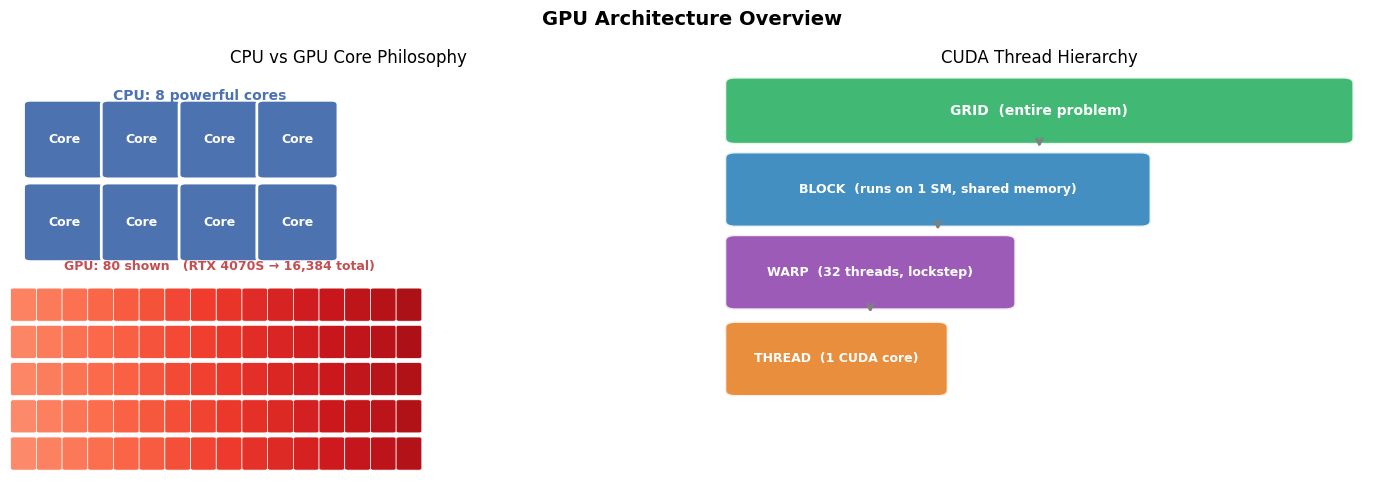

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("GPU Architecture Overview", fontsize=14, fontweight='bold')

# ── Left: CPU vs GPU core count ──────────────────────────────────────────────
ax = axes[0]
ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.axis('off')
ax.set_title("CPU vs GPU Core Philosophy", fontsize=12)

# CPU — 8 big cores
for i in range(4):
    for j in range(2):
        r = mpatches.FancyBboxPatch((0.3+i*1.15, 5.5+j*2.0), 1.0, 1.7,
            boxstyle="round,pad=0.1", facecolor='#4C72B0', edgecolor='white', lw=2)
        ax.add_patch(r)
        ax.text(0.80+i*1.15, 6.35+j*2.0, 'Core', ha='center', va='center',
                color='white', fontsize=9, fontweight='bold')
ax.text(2.8, 9.3, 'CPU: 8 powerful cores', ha='center', fontsize=10,
        color='#4C72B0', fontweight='bold')

# GPU — many small cores
cmap = plt.cm.Reds(np.linspace(0.4, 0.85, 80))
for i in range(16):
    for j in range(5):
        r = mpatches.FancyBboxPatch((0.05+i*0.38, 0.4+j*0.9), 0.30, 0.72,
            boxstyle="round,pad=0.04", facecolor=cmap[i*5+j], edgecolor='white', lw=0.5)
        ax.add_patch(r)
ax.text(3.1, 5.2, 'GPU: 80 shown   (RTX 4070S → 16,384 total)', ha='center',
        fontsize=9, color='#C44E52', fontweight='bold')

# ── Right: thread hierarchy ───────────────────────────────────────────────────
ax2 = axes[1]
ax2.set_xlim(0, 10); ax2.set_ylim(0, 10.5); ax2.axis('off')
ax2.set_title("CUDA Thread Hierarchy", fontsize=12)

levels = [
    (5.0, 9.5, 9.0, 1.4, '#27ae60', 'GRID  (entire problem)', 10),
    (3.5, 7.5, 6.0, 1.6, '#2980b9', 'BLOCK  (runs on 1 SM, shared memory)', 9),
    (2.5, 5.4, 4.0, 1.6, '#8e44ad', 'WARP  (32 threads, lockstep)', 9),
    (2.0, 3.2, 3.0, 1.6, '#e67e22', 'THREAD  (1 CUDA core)', 9),
]
for x, y, w, h, color, label, fs in levels:
    r = mpatches.FancyBboxPatch((x-w/2, y-h/2), w, h,
        boxstyle="round,pad=0.15", facecolor=color, edgecolor='white', lw=2, alpha=0.88)
    ax2.add_patch(r)
    ax2.text(x, y, label, ha='center', va='center', fontsize=fs,
             fontweight='bold', color='white')
    if y > 3.5:
        ax2.annotate('', xy=(x, y-h/2-0.3), xytext=(x, y-h/2),
            arrowprops=dict(arrowstyle='->', color='gray', lw=2))

plt.tight_layout()
plt.show()


## 2. CUDA Execution Model & Thread Indexing

Every CUDA thread has access to built-in variables that tell it who it is:

```c
threadIdx.x   // thread's index within its block  (0 → blockDim.x - 1)
blockIdx.x    // block's index within the grid    (0 → gridDim.x - 1)
blockDim.x    // number of threads per block
```

**Computing a unique global index (1D):**
```c
int idx = blockIdx.x * blockDim.x + threadIdx.x;
```

**Choosing launch parameters in Python:**
```python
threads_per_block = 256    # how many threads run per block
                           # must be a multiple of 32 (warp size), max is 1024

n = 1_000_000              # the size of your problem — e.g. number of array elements
                           # each thread will handle one element, so you need at least n threads total

blocks = (n + threads_per_block - 1) // threads_per_block   # ← ceiling division
# Why ceiling division?
# You need enough blocks so that blocks × threads_per_block >= n.
# Plain division (n // threads_per_block) rounds DOWN, which would leave
# the last few elements unprocessed if n isn't a perfect multiple of threads_per_block.
# Adding (threads_per_block - 1) before dividing forces it to round UP instead.
#
# Example: n=1000, threads_per_block=256
#   plain:   1000 // 256 = 3  →  3 × 256 = 768 threads  (misses 232 elements!)
#   ceiling: (1000 + 255) // 256 = 4  →  4 × 256 = 1024 threads  (covers all 1000)
#
# The extra threads (indices 1000–1023) are harmless — the kernel guards against them:
#   if (idx < n) { ... }

kernel((blocks,), (threads_per_block,), args)
```

> **Always guard with** `if (idx < n)` to handle threads past the end of your array.


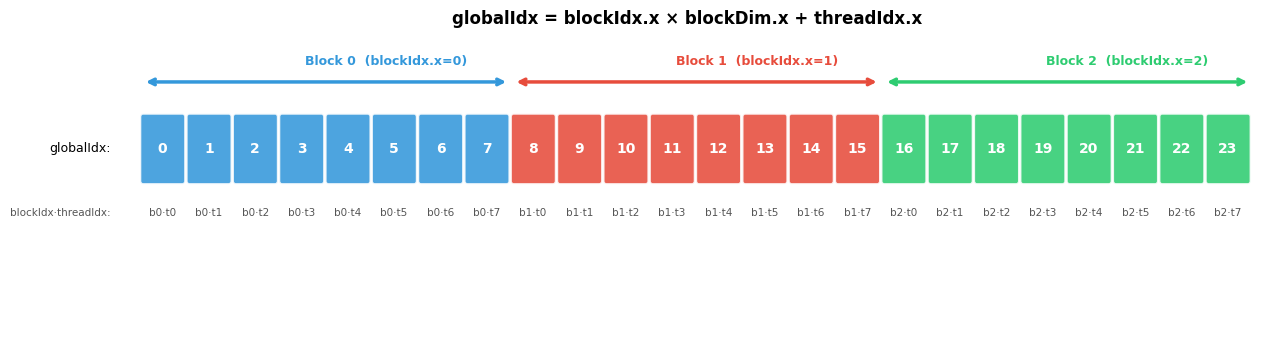

In [33]:
# Visualize how threadIdx + blockIdx maps to a global index
tpb   = 8    # threads per block (small for illustration)
n_blk = 3    # number of blocks
N     = tpb * n_blk

fig, ax = plt.subplots(figsize=(13, 3.5))
ax.set_title("globalIdx = blockIdx.x × blockDim.x + threadIdx.x", fontsize=12, fontweight='bold')
ax.set_xlim(-1, N+0.5); ax.set_ylim(-1.5, 4.5); ax.axis('off')

colors = ['#3498db', '#e74c3c', '#2ecc71']

for g in range(N):
    bid = g // tpb
    tid = g % tpb
    c   = colors[bid]
    rect = mpatches.FancyBboxPatch((g, 1.5), 0.85, 1.3,
        boxstyle="round,pad=0.06", facecolor=c, edgecolor='white', lw=1.5, alpha=0.88)
    ax.add_patch(rect)
    ax.text(g+0.42, 2.15, str(g), ha='center', va='center', fontsize=10,
            fontweight='bold', color='white')
    ax.text(g+0.42, 0.85, f'b{bid}·t{tid}', ha='center', va='center',
            fontsize=7.5, color='#555')

for b in range(n_blk):
    s, e = b*tpb, (b+1)*tpb
    ax.annotate('', xy=(e-0.1, 3.5), xytext=(s, 3.5),
        arrowprops=dict(arrowstyle='<->', color=colors[b], lw=2.5))
    ax.text((s+e)/2 - 0.5, 3.85, f'Block {b}  (blockIdx.x={b})',
            fontsize=9, color=colors[b], fontweight='bold')

ax.text(-0.7, 2.15, 'globalIdx:', fontsize=9, ha='right', va='center')
ax.text(-0.7, 0.85, 'blockIdx·threadIdx:', fontsize=7.5, ha='right', va='center', color='#555')
plt.tight_layout()
plt.show()


## 3. Your First CUDA Kernel: Vector Addition

`cp.RawKernel` lets you write **real CUDA C** inside a Python string — no abstraction layer.

**Key CUDA qualifiers:**

| Qualifier | Meaning |
|-----------|---------|
| `__global__` | Called from CPU, runs on GPU |
| `__device__` | Called from GPU only |
| `__shared__` | Variable lives in on-chip shared memory |
| `extern "C"` | Prevents C++ name mangling so CuPy can find the kernel by name |

---

**`__global__`** — the main kernel, launched from Python, runs on the GPU:
```c
extern "C" __global__
void vector_add(const float* a, const float* b, float* c, int n) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx < n) c[idx] = a[idx] + b[idx];
}
// called from Python: kernel((blocks,), (threads,), args)
```

---

**`__device__`** — a helper function callable only from inside the GPU (from `__global__` or other `__device__` functions):
```c
__device__
float square(float x) {
    return x * x;   // runs on GPU, cannot be called from Python
}

extern "C" __global__
void apply_square(float* arr, int n) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx < n) arr[idx] = square(arr[idx]);  // calls __device__ from __global__
}
```

---

**`__shared__`** — a variable that lives in fast on-chip shared memory, shared by all threads in the same block:
```c
extern "C" __global__
void sum_block(const float* data, float* result, int n) {
    __shared__ float tile[256];   // one copy of this array per block, ~100x faster than global memory

    int idx  = blockIdx.x * blockDim.x + threadIdx.x;
    int lane = threadIdx.x;

    tile[lane] = (idx < n) ? data[idx] : 0.0f;  // each thread loads one element
    __syncthreads();                              // wait for all threads to finish loading

    // now all threads can read any element of tile[] cheaply
    if (lane == 0) result[blockIdx.x] = tile[0] + tile[1];  // example: thread 0 reads tile
}
```

---

**`extern "C"`** — tells the C++ compiler not to mangle the function name, so CuPy can look it up:
```c
// WITHOUT extern "C": compiler stores it as "_Z10vector_addPKfS0_Pfi"
//                     CuPy searches for "vector_add" → not found → crash
__global__ void vector_add(...) { ... }

// WITH extern "C": compiler stores it as "vector_add"
//                  CuPy searches for "vector_add" → found ✅
extern "C" __global__ void vector_add(...) { ... }
```


In [34]:
# ── Vector Addition: C[i] = A[i] + B[i] ─────────────────────────────────────

vector_add = cp.RawKernel(r'''
extern "C" __global__
void vector_add(const float* a, const float* b, float* c, int n) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx < n) {
        c[idx] = a[idx] + b[idx];
    }
}
''', 'vector_add')

N       = 1_000_000
THREADS = 256
BLOCKS  = (N + THREADS - 1) // THREADS

a_gpu = cp.random.rand(N, dtype=cp.float32)
b_gpu = cp.random.rand(N, dtype=cp.float32)
c_gpu = cp.zeros(N, dtype=cp.float32)

print(f"Launching {BLOCKS:,} blocks × {THREADS} threads = {BLOCKS*THREADS:,} total threads")

vector_add((BLOCKS,), (THREADS,), (a_gpu, b_gpu, c_gpu, N))
cp.cuda.Stream.null.synchronize()

# Use numpy comparison to avoid NVRTC CUB reduction compilation issues
print(f"\n✅ Correct: {np.allclose(c_gpu.get(), (a_gpu + b_gpu).get())}")
print(f"   a[:5]      = {a_gpu[:5]}")
print(f"   b[:5]      = {b_gpu[:5]}")
print(f"   c[:5]      = {c_gpu[:5]}")


Launching 3,907 blocks × 256 threads = 1,000,192 total threads

✅ Correct: True
   a[:5]      = [0.57537514 0.2419691  0.1618118  0.9929337  0.6188304 ]
   b[:5]      = [0.96275973 0.47685242 0.10777437 0.7968182  0.837376  ]
   c[:5]      = [1.5381348  0.7188215  0.26958618 1.7897519  1.4562063 ]


---
## 🎯 Challenge 1: Scalar Multiply Kernel

Write a CUDA kernel that multiplies every element of an array by a scalar **in-place**.

**Signature:** `void scalar_multiply(float* arr, float scalar, int n)`

**Requirements:**
- Each thread processes one element
- Modify `arr[idx]` in-place
- Guard against out-of-bounds access

**Hint:** It's very similar to vector_add — one line of work per thread.

---

### 🧠 AI connection: gradient descent
This is exactly what happens every training step when updating weights:

```python
# Python (slow, serial):
for i in range(len(weights)):
    weights[i] -= learning_rate * gradients[i]   # scalar multiply + subtract

# GPU version — all weights updated simultaneously:
scalar_multiply(gradients, learning_rate, n)     # your kernel scales the gradient
vector_subtract(weights, gradients, n)           # then subtract in one parallel pass
```

GPT-3 has 175 billion weights. On CPU this loop takes minutes. On GPU: milliseconds.


In [35]:
# ✏️ YOUR TASK: complete the kernel body

scalar_multiply = cp.RawKernel(r'''
extern "C" __global__
void scalar_multiply(float* arr, float scalar, int n) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;

    // ✏️ YOUR CODE HERE
    if(idx < n) arr[idx] = arr[idx] * scalar;
    //    Multiply arr[idx] by scalar, in-place.
    //    Don't forget: guard against idx >= n!

}
''', 'scalar_multiply')


In [36]:
# ── Auto-test: Challenge 1 ────────────────────────────────────────────────────
import traceback

def test_scalar_multiply():
    cases = [(1_000_000, 3.14), (777, 0.5), (1025, -2.0), (1, 7.0)]
    THREADS = 256
    passed = 0
    for n, s in cases:
        arr = cp.full(n, 2.0, dtype=cp.float32)
        expected = arr * s
        blk = (n + THREADS - 1) // THREADS
        try:
            scalar_multiply((blk,), (THREADS,), (arr, cp.float32(s), n))
            cp.cuda.Stream.null.synchronize()
            ok = np.allclose(arr.get(), expected.get(), atol=1e-5)
            icon = "✅" if ok else "❌"
            print(f"  {icon} n={n:>9,}  scalar={s:>5}  result[0]={float(arr[0]):.4f}  "
                  f"expected={float(expected[0]):.4f}")
            if ok: passed += 1
        except Exception as e:
            print(f"  💥 ERROR  n={n}: {e}")
    print()
    if passed == len(cases):
        print("🏆 All tests passed!")
    else:
        print(f"🔧 {len(cases)-passed}/{len(cases)} test(s) failed — check your kernel.")

test_scalar_multiply()


  ✅ n=1,000,000  scalar= 3.14  result[0]=6.2800  expected=6.2800
  ✅ n=      777  scalar=  0.5  result[0]=1.0000  expected=1.0000
  ✅ n=    1,025  scalar= -2.0  result[0]=-4.0000  expected=-4.0000
  ✅ n=        1  scalar=  7.0  result[0]=14.0000  expected=14.0000

🏆 All tests passed!


## 4. GPU Memory Hierarchy

```
┌────────────────────────────────────────────────────────────┐
│                        GRID                                │
│  ┌──────────────────────────────────────────┐              │
│  │                  BLOCK                   │              │
│  │  ┌────────────────────────────────────┐  │              │
│  │  │  Shared Memory  (~48 KB/SM)        │  │              │
│  │  │  On-chip SRAM · ~19 TB/s          │  │              │
│  │  │  Shared by all threads in block    │  │              │
│  │  └────────────────────────────────────┘  │              │
│  │  ┌──────┐ ┌──────┐ ┌──────┐ ...          │              │
│  │  │Regs  │ │Regs  │ │Regs  │  ← per thread│              │
│  │  └──────┘ └──────┘ └──────┘              │              │
│  └──────────────────────────────────────────┘              │
│                         │                                  │
│           L2 Cache (48 MB)                                 │
│           ~4 TB/s · shared across all SMs                  │
│                         │                                  │
│           Global Memory (12 GB GDDR6X)                     │
│           ~900 GB/s · accessible by all threads            │
└────────────────────────────────────────────────────────────┘
                           │
                  Host RAM (PCIe 4.0 ~32 GB/s)
```

| Memory | Size | Bandwidth | Latency | Scope |
|--------|------|-----------|---------|-------|
| Registers | ~256 KB/SM | ~19 TB/s | **1 cycle** | Per thread |
| Shared Memory (L1) | ~48 KB/block | ~19 TB/s | **~32 cycles** | Per block |
| L2 Cache | 48 MB | ~4 TB/s | **~200 cycles** | All threads |
| Global (VRAM) | 12 GB | ~900 GB/s | **~600–800 cycles** | All threads |
| Host RAM | Unlimited | ~32 GB/s (PCIe) | **~20,000+ cycles** | CPU only |

> **Rule:** Minimize Host↔Device transfers. Use shared memory to cache hot data.  
> Registers are instant (1 cycle) — global memory is ~700× slower. This gap is why shared memory exists.


In [20]:
# ── Measure actual memory bandwidth ──────────────────────────────────────────

THREADS = 256
N_MB    = 512
n       = N_MB * 1024 * 1024 // 4    # float32 elements

a = cp.random.rand(n, dtype=cp.float32)
b = cp.zeros_like(a)

# Warmup
cp.copyto(b, a); cp.cuda.Stream.null.synchronize()

# GPU global memory bandwidth (copy = read + write)
N_RUNS = 20
t0 = cp.cuda.Event(); t1 = cp.cuda.Event()
t0.record()
for _ in range(N_RUNS):
    cp.copyto(b, a)
t1.record(); t1.synchronize()

elapsed_ms = cp.cuda.get_elapsed_time(t0, t1) / N_RUNS
bytes_moved = 2 * n * 4    # read n floats + write n floats
gpu_bw = bytes_moved / (elapsed_ms * 1e-3) / 1e9

# Host→Device transfer (PCIe)
cpu_arr = np.random.rand(n).astype(np.float32)
t = time.perf_counter()
gpu_tmp = cp.asarray(cpu_arr)
cp.cuda.Stream.null.synchronize()
h2d_bw = (n * 4) / (time.perf_counter() - t) / 1e9

# Device→Host
t = time.perf_counter()
_ = cp.asnumpy(gpu_tmp)
d2h_bw = (n * 4) / (time.perf_counter() - t) / 1e9

print("📊 Bandwidth Results")
print(f"  GPU Global Memory   : {gpu_bw:.0f} GB/s")
print(f"  Host → Device PCIe  : {h2d_bw:.1f} GB/s")
print(f"  Device → Host PCIe  : {d2h_bw:.1f} GB/s")
print(f"\n  GPU internal is {gpu_bw/h2d_bw:.0f}× faster than PCIe!")
print(f"  → Minimize CPU↔GPU transfers, do as much as possible on-device.")


📊 Bandwidth Results
  GPU Global Memory   : 411 GB/s
  Host → Device PCIe  : 11.0 GB/s
  Device → Host PCIe  : 13.1 GB/s

  GPU internal is 37× faster than PCIe!
  → Minimize CPU↔GPU transfers, do as much as possible on-device.


## 5. Shared Memory & Parallel Reduction

Shared memory is **on-chip SRAM** — ~100× faster than global memory for random access.

**Pattern — load → sync → compute → write:**
```c
__global__ void kernel(float* data, int n) {
    __shared__ float tile[256];          // fast on-chip buffer

    int idx  = blockIdx.x * blockDim.x + threadIdx.x;
    int lane = threadIdx.x;

    // Step 1: load from slow global into fast shared
    tile[lane] = (idx < n) ? data[idx] : 0.0f;

    __syncthreads();   // ← BARRIER: all threads must reach this before any can pass

    // Step 2: work with fast shared memory ...

    // Step 3: write result back to global
    if (idx < n) data[idx] = tile[lane] * 2.0f;
}
```

### Parallel Tree Reduction
To sum N values cooperatively within a block, use a **tree-shaped reduction**:

```
Round 1 (stride=128): thread 0 += thread 128,  thread 1 += thread 129, ...
Round 2 (stride=64):  thread 0 += thread 64,   thread 1 += thread 65, ...
Round 3 (stride=32):  thread 0 += thread 32,   ...
...
Round 8 (stride=1):   thread 0 holds the total block sum
```
Completes in **log₂(blockSize)** steps instead of N — O(log N) vs O(N).


In [21]:
# ── Dot product with shared memory reduction ─────────────────────────────────

dot_product = cp.RawKernel(r'''
extern "C" __global__
void dot_product(const float* a, const float* b, float* partial, int n) {
    __shared__ float tile[256];

    int idx  = blockIdx.x * blockDim.x + threadIdx.x;
    int lane = threadIdx.x;

    // Step 1: each thread computes its a[i]*b[i], load into shared mem
    tile[lane] = (idx < n) ? a[idx] * b[idx] : 0.0f;
    __syncthreads();

    // Step 2: parallel tree reduction within this block
    for (int stride = blockDim.x / 2; stride > 0; stride >>= 1) {
        if (lane < stride) {
            tile[lane] += tile[lane + stride];
        }
        __syncthreads();
    }

    // Step 3: thread 0 writes block result to global partial sums
    if (lane == 0) {
        partial[blockIdx.x] = tile[0];
    }
}
''', 'dot_product')

N       = 1 << 20    # 1M elements
THREADS = 256
BLOCKS  = (N + THREADS - 1) // THREADS

a = cp.random.rand(N, dtype=cp.float32)
b = cp.random.rand(N, dtype=cp.float32)
partial = cp.zeros(BLOCKS, dtype=cp.float32)

dot_product((BLOCKS,), (THREADS,), (a, b, partial, N))
cp.cuda.Stream.null.synchronize()

our_result  = float(partial.sum())     # final reduction on GPU
cupy_result = float(cp.dot(a, b))

print(f"Our kernel : {our_result:.4f}")
print(f"CuPy dot   : {cupy_result:.4f}")
rel_err = abs(our_result - cupy_result) / abs(cupy_result)
print(f"Rel error  : {rel_err:.2e}  {'✅' if rel_err < 1e-3 else '❌'}")


Our kernel : 261940.8281
CuPy dot   : 261940.8125
Rel error  : 5.97e-08  ✅


---
## 🎯 Challenge 2: Parallel Maximum (Reduction)

Using the shared memory reduction pattern above, write a kernel that finds the **maximum value** in each block.

**Signature:** `void block_max(const float* data, float* partial_maxes, int n)`

**Requirements:**
- Load one element per thread into shared memory (use `-3.4028235e+38f` for out-of-bounds threads)
- Use parallel tree reduction, replacing addition with **`fmaxf(a, b)`** (CUDA's float max)
- Thread 0 writes the block's maximum to `partial_maxes[blockIdx.x]`

**On the Python side:** `float(partial_maxes.max())` gives the global maximum.

**Hint:** Only change the operation inside the reduction loop — the structure is identical to dot_product.

---

### 🧠 AI connection: numerically stable softmax
Softmax is used in every Transformer model (GPT, BERT) to turn raw scores into probabilities.
The naive version overflows with large numbers, so you first subtract the maximum:

```
naive softmax:   exp(x[i]) / sum(exp(x))          ← exp(1000) = inf, crashes

stable softmax:  exp(x[i] - max(x)) / sum(exp(x - max(x)))   ← safe, same result
```

Step 1 of stable softmax is finding `max(x)` across the entire array — exactly what your
`block_max` kernel does. This is called a **reduction**: many values → one result.

Other reductions used in AI:
- `sum` → cross-entropy loss, layer normalization
- `max` → stable softmax (this challenge)
- `dot product` → attention scores, cosine similarity


In [22]:
# ✏️ YOUR TASK: complete the block_max kernel

block_max = cp.RawKernel(r'''
extern "C" __global__
void block_max(const float* data, float* partial_maxes, int n) {
    __shared__ float tile[256];

    int idx  = blockIdx.x * blockDim.x + threadIdx.x;
    int lane = threadIdx.x;

    // Step 1: load (use -FLT_MAX sentinel for out-of-bounds threads)
    tile[lane] = (idx < n) ? data[idx] : -3.4028235e+38f;
    __syncthreads();

    // ✏️ Step 2: parallel tree reduction — find maximum instead of sum
    //    Replace addition with fmaxf(tile[lane], tile[lane + stride])


    // ✏️ Step 3: thread 0 writes block result to partial_maxes[blockIdx.x]

}
''', 'block_max')


In [23]:
# ── Auto-test: Challenge 2 ────────────────────────────────────────────────────

def test_block_max():
    cases = [
        (1_000_000, "large array"),
        (777,       "non-power-of-2"),
        (256,       "exactly 1 block"),
        (1,         "single element"),
    ]
    THREADS = 256
    passed  = 0
    for n, desc in cases:
        data = cp.random.rand(n, dtype=cp.float32) * 100
        data[n // 2] = 999.0    # plant a known maximum
        blk = (n + THREADS - 1) // THREADS
        partial = cp.full(blk, -1e38, dtype=cp.float32)
        try:
            block_max((blk,), (THREADS,), (data, partial, n))
            cp.cuda.Stream.null.synchronize()
            result   = float(partial.max())
            expected = float(data.max())
            ok = abs(result - expected) < 1e-3
            icon = "✅" if ok else "❌"
            print(f"  {icon} {desc:22s}  max={result:.2f}  expected={expected:.2f}")
            if ok: passed += 1
        except Exception as e:
            print(f"  💥 ERROR  {desc}: {e}")
    print()
    if passed == len(cases):
        print("🏆 All tests passed!")
    else:
        print(f"🔧 {len(cases)-passed}/{len(cases)} test(s) failed — check your reduction loop.")

test_block_max()


  ❌ large array             max=-99999996802856924650656260769173209088.00  expected=999.00
  ❌ non-power-of-2          max=-99999996802856924650656260769173209088.00  expected=999.00
  ❌ exactly 1 block         max=-99999996802856924650656260769173209088.00  expected=999.00
  ❌ single element          max=-99999996802856924650656260769173209088.00  expected=999.00

🔧 4/4 test(s) failed — check your reduction loop.


## 6. 2D Thread Indexing

Many problems are naturally 2D (images, matrices). CUDA supports 2D grids and blocks.

```c
__global__ void kernel_2d(float* mat, int rows, int cols) {
    int col = blockIdx.x * blockDim.x + threadIdx.x;   // x-axis → columns
    int row = blockIdx.y * blockDim.y + threadIdx.y;   // y-axis → rows

    if (row < rows && col < cols) {
        int flat_idx = row * cols + col;               // row-major (C order)
        mat[flat_idx] = /* ... */;
    }
}
```

**Launch with 2D block/grid:**
```python
BLOCK = (16, 16)     # 256 threads per block, in a 16×16 tile
grid_x = (cols + 15) // 16
grid_y = (rows + 15) // 16
kernel((grid_x, grid_y), BLOCK, args)
```

> **Tile size 16×16 = 256 threads** is a common choice for 2D problems.  
> 32×32 = 1024 threads (max per block) — may give higher occupancy for large matrices.


In [24]:
# ── Matrix Transpose: out[col][row] = in[row][col] ───────────────────────────

transpose = cp.RawKernel(r'''
extern "C" __global__
void transpose(const float* in, float* out, int rows, int cols) {
    int col = blockIdx.x * blockDim.x + threadIdx.x;
    int row = blockIdx.y * blockDim.y + threadIdx.y;

    if (row < rows && col < cols) {
        // Read from [row][col] in row-major input
        // Write to [col][row] in row-major output  (transposed layout)
        out[col * rows + row] = in[row * cols + col];
    }
}
''', 'transpose')

ROWS, COLS = 2048, 4096
A = cp.arange(ROWS * COLS, dtype=cp.float32).reshape(ROWS, COLS)
B = cp.zeros((COLS, ROWS), dtype=cp.float32)

BLOCK = (16, 16)
GRID  = ((COLS + 15) // 16, (ROWS + 15) // 16)

transpose(GRID, BLOCK, (A, B, ROWS, COLS))
cp.cuda.Stream.null.synchronize()

print(f"Input shape  : {A.shape}")
print(f"Output shape : {B.shape}")
# Use numpy comparison to avoid NVRTC CUB reduction compilation issues
print(f"✅ Correct    : {np.allclose(B.get(), A.T.get())}")
print(f"\nA[0:3, 0:3]:\n{A[:3,:3]}")
print(f"\nB[0:3, 0:3] (should be A.T):\n{B[:3,:3]}")


Input shape  : (2048, 4096)
Output shape : (4096, 2048)
✅ Correct    : True

A[0:3, 0:3]:
[[0.000e+00 1.000e+00 2.000e+00]
 [4.096e+03 4.097e+03 4.098e+03]
 [8.192e+03 8.193e+03 8.194e+03]]

B[0:3, 0:3] (should be A.T):
[[0.000e+00 4.096e+03 8.192e+03]
 [1.000e+00 4.097e+03 8.193e+03]
 [2.000e+00 4.098e+03 8.194e+03]]


---
## 🎯 Challenge 3: Matrix–Vector Multiplication

Write a kernel that multiplies matrix `A` (M×N) by vector `x` (N,) to produce `y` (M,).

$$y[i] = \sum_{j=0}^{N-1} A[i][j] \cdot x[j]$$

**Signature:** `void matvec(const float* A, const float* x, float* y, int M, int N)`

**Requirements:**
- Each thread computes **one output element** `y[i]` (i = thread's row)
- Use 1D thread blocks across the M dimension
- Loop over columns `j` from 0 to N–1 inside the thread
- `A` is stored row-major: `A[i][j]` → `A[i*N + j]`

**Launch:**
```python
THREADS = 256
BLOCKS  = (M + THREADS - 1) // THREADS
matvec((BLOCKS,), (THREADS,), (A, x, y, M, N))
```

**Hint:** Start with `float sum = 0.0f;`, loop over j, accumulate, then write `y[i] = sum`.

---

### 🧠 AI connection: the linear layer — the most fundamental operation in deep learning
Every neural network layer is built on matrix multiplication:

```
Linear layer:   y = W @ x + b

  W = weight matrix  (M × N)  — learned parameters
  x = input vector   (N,)     — activations from previous layer
  b = bias vector    (M,)     — learned offset
  y = output vector  (M,)     — activations passed to next layer
```

**Real example — one GPT-2 small attention layer:**
- `W` shape: (768, 768) — 589,824 weights
- `x` shape: (768,) — one token's embedding
- Your kernel computes this in parallel: all 768 output values simultaneously

This matvec is the building block of:
- **Feed-forward layers** in every Transformer (GPT, BERT, LLaMA)
- **Embedding lookups** in NLP models
- **Fully connected layers** in Computer Vision (ResNet classifier head)
- **Recommendation systems** (user embedding × item matrix)

In production, batched matmul (`W @ X` where X has many columns) is used instead,
but the per-row dot product your kernel computes is the same fundamental operation.


In [10]:
# ✏️ YOUR TASK: complete the matvec kernel

matvec = cp.RawKernel(r'''
extern "C" __global__
void matvec(const float* A, const float* x, float* y, int M, int N) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;   // row index

    if (i < M) {
        float sum = 0.0f;

        // ✏️ YOUR CODE HERE:
        //    Loop over j from 0 to N-1
        //    Accumulate A[i*N + j] * x[j] into sum
        //    Then: y[i] = sum

    }
}
''', 'matvec')


In [11]:
# ── Auto-test: Challenge 3 ────────────────────────────────────────────────────

def test_matvec():
    cases = [(512, 512), (1000, 768), (3, 4), (1, 1)]
    THREADS = 256
    passed  = 0
    for M, N in cases:
        A = cp.random.rand(M, N, dtype=cp.float32)
        x = cp.random.rand(N, dtype=cp.float32)
        y = cp.zeros(M, dtype=cp.float32)
        blk = (M + THREADS - 1) // THREADS
        try:
            matvec((blk,), (THREADS,), (A, x, y, M, N))
            cp.cuda.Stream.null.synchronize()
            expected = A @ x
            ok = cp.allclose(y, expected, atol=1e-4)
            icon = "✅" if ok else "❌"
            diff = float(cp.max(cp.abs(y - expected)))
            print(f"  {icon} A({M}×{N}) @ x({N},) → y({M},)  y[0]={float(y[0]):.4f}  "
                  f"expected={float(expected[0]):.4f}  max_diff={diff:.2e}")
            if ok: passed += 1
        except Exception as e:
            print(f"  💥 ERROR  ({M}×{N}): {e}")
    print()
    if passed == len(cases):
        print("🏆 All tests passed! You can write GPU linear algebra kernels!")
    else:
        print(f"🔧 {len(cases)-passed}/{len(cases)} test(s) failed — check your inner loop.")

test_matvec()


  💥 ERROR  (512×512): /opt/cuda/include/cuda_fp8.hpp(1498): error: this declaration has no storage class or type specifier
      __NV_SILENCE_DEPRECATION_BEGIN
      ^

/opt/cuda/include/cuda_fp8.hpp(1499): error: expected a ";"
      explicit __CUDA_HOSTDEVICE_FP8__ __nv_fp8x4_e5m2(const double4 f) {
      ^

/opt/cuda/include/cuda_fp8.hpp(1559): warning #12-D: parsing restarts here after previous syntax error
  };
  ^

Remark: The warnings can be suppressed with "-diag-suppress <warning-number>"

/opt/cuda/include/cuda_fp8.hpp(2127): error: this declaration has no storage class or type specifier
      __NV_SILENCE_DEPRECATION_BEGIN
      ^

/opt/cuda/include/cuda_fp8.hpp(2128): error: expected a ";"
      explicit __CUDA_HOSTDEVICE_FP8__ __nv_fp8x4_e4m3(const double4 f) {
      ^

/opt/cuda/include/cuda_fp8.hpp(2188): warning #12-D: parsing restarts here after previous syntax error
  };
  ^

/opt/cuda/include/cuda_fp8.hpp(2776): error: this declaration has no storage class or type sp

In [12]:
# ── L1 & L2 Cache Sizes ──────────────────────────────────────────────────────
props = cp.cuda.runtime.getDeviceProperties(0)

# L2 cache – reported directly in the device-properties struct
l2_bytes = props['l2CacheSize']

# L1 cache – not a separate field; it shares the on-chip SRAM with shared memory.
# 'sharedMemPerMultiprocessor' gives the *total* on-chip SRAM per SM, which is
# the pool that the driver partitions into L1 cache + shared memory at runtime.
l1_pool_bytes = props['sharedMemPerMultiprocessor']

# For reference: shared memory available to a single block
shmem_per_block = props['sharedMemPerBlock']

print(f"{'─'*55}")
print(f"  Cache / On-chip memory sizes — {props['name'].decode()}")
print(f"{'─'*55}")
print(f"  L2 cache (device-wide)       : {l2_bytes / 1024**2:.1f} MB  ({l2_bytes:,} bytes)")
print(f"  L1 + shared mem pool (per SM): {l1_pool_bytes / 1024:.0f} KB  ({l1_pool_bytes:,} bytes)")
print(f"  Max shared mem (per block)   : {shmem_per_block / 1024:.0f} KB  ({shmem_per_block:,} bytes)")
print(f"{'─'*55}")
print()
print("  Note: L1 and shared memory share the same on-chip SRAM bank per SM.")
print("  The split is configurable via cudaFuncSetCacheConfig() (e.g. prefer")
print("  L1 vs. prefer shared mem). 'sharedMemPerMultiprocessor' is the total")
print("  pool; typical default is 50% L1 / 50% shared on modern GPUs.")

───────────────────────────────────────────────────────
  Cache / On-chip memory sizes — NVIDIA GeForce RTX 4070 SUPER
───────────────────────────────────────────────────────
  L2 cache (device-wide)       : 48.0 MB  (50,331,648 bytes)
  L1 + shared mem pool (per SM): 100 KB  (102,400 bytes)
  Max shared mem (per block)   : 48 KB  (49,152 bytes)
───────────────────────────────────────────────────────

  Note: L1 and shared memory share the same on-chip SRAM bank per SM.
  The split is configurable via cudaFuncSetCacheConfig() (e.g. prefer
  L1 vs. prefer shared mem). 'sharedMemPerMultiprocessor' is the total
  pool; typical default is 50% L1 / 50% shared on modern GPUs.


---
## ✅ Module 1 Summary

| Concept | What you learned | AI relevance |
|---------|-----------------|--------------|
| **GPU Architecture** | SMs, CUDA cores, warp size (32), memory hierarchy | Why GPUs dominate AI training |
| **Thread Hierarchy** | Thread → Warp → Block → Grid | Maps directly to tensor dimensions |
| **Thread Indexing** | `blockIdx.x * blockDim.x + threadIdx.x` | Used in every production kernel |
| **RawKernel** | Writing real CUDA C kernels in Python | How NVIDIA libraries like cuDNN are built |
| **Bounds guard** | `if (idx < n)` pattern | Prevents silent data corruption |
| **Shared Memory** | Fast on-chip SRAM + `__syncthreads()` | Key to high-performance attention kernels |
| **Parallel Reduction** | Tree-shaped sum/max in O(log N) | Loss computation, softmax, layer norm |
| **2D Indexing** | `blockIdx.x/.y`, `threadIdx.x/.y` | Image processing, matrix operations |

### How these map to real AI workloads

```
Neural network forward pass:
  x = input
  x = linear(x)      →  matvec kernel       (Challenge 3)
  x = x + bias       →  vector_add kernel   (Section 3)
  x = relu(x)        →  scalar kernel       (like Challenge 1)
  loss = cross_entropy(x, y)
       = -sum(log(softmax(x)))
       = -sum(log(exp(x - max(x)) / sum(exp(x - max(x)))))
              ↑                ↑              ↑
          block_max       block_max       dot_product
         (Challenge 2)   (Challenge 2)   (Section 5)
```

---

### 🔜 Module 2 Preview — Performance Optimization
- **Coalesced memory access** — why stride-1 access is 10× faster (critical for matmul)
- **Pinned memory** — faster Host↔Device transfers for data loading
- **Unified memory** — zero-copy arrays
- **Roofline model** — are you memory-bound or compute-bound?
- **Occupancy** — how to keep all SMs busy

### 📖 Resources
- [CUDA C++ Programming Guide](https://docs.nvidia.com/cuda/cuda-c-programming-guide/)
- [CuPy RawKernel docs](https://docs.cupy.dev/en/stable/user_guide/kernel.html)
- [NVIDIA Ada Lovelace Architecture](https://www.nvidia.com/en-us/geforce/ada-lovelace-architecture/)
